## Pre testing (president)

Here before trying a combination of multiple models, we will define a foundation on how we will run our models.

In [9]:
from preprocessing_class import Preprocessing, load_pres
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split, StratifiedKFold
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC,SVC
from nltk.corpus import stopwords
import numpy as np
import string
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# load dataset
alltxt, alllabs = load_pres("Dataset/corpus.tache1.learn.utf8")
alltxt, alllabs = np.array(alltxt), np.array(alllabs)
alllabs = np.where(alllabs == 1, 0, 1)
# M = -1, C = 1
len(alltxt), len(alllabs), np.unique(alllabs)

(57413, 57413, array([0, 1]))

In [4]:
# train test split here for test in final prediction

X_train, X_test, y_train, y_test = train_test_split(
    alltxt, alllabs, 
    test_size=0.20, 
    stratify=alllabs, 
    random_state=42
)

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.20, 
    stratify=y_train, 
    random_state=42
)

len(X_train_sub), len(y_train_sub), len(X_val), len(y_val), len(X_train), len(y_train), len(X_test), len(y_test)

(36744, 36744, 9186, 9186, 45930, 45930, 11483, 11483)

### 1.Training time based on vocabulary size, for different modèles

In [5]:
punc = set(string.punctuation + '\n\r\t')
punc.remove("'") # keep the ' for french words 
custom_punctuation = "".join(punc)

prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

In [6]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.ensemble import RandomForestClassifier

final_stopwords_list = stopwords.words('french') # stopwords.words('english') 

def build_vectorizer(name="count", stop_words=None, max_features=None,
                     lowercase=False, strip_accents=None, ngram_range=(1,1), use_idf= True, smooth_idf=True, sublinear_tf=False, 
                     max_df=0.95, min_df=2, preprocessor = lambda x: x):
    if name == "count":
        vectorizer = CountVectorizer(stop_words=stop_words,max_features=max_features,max_df=max_df,min_df=min_df,ngram_range=ngram_range,lowercase=lowercase,
                                     strip_accents=strip_accents, preprocessor=preprocessor)    
        
    elif name == "tfidf":
        vectorizer = TfidfVectorizer(use_idf= use_idf, smooth_idf=smooth_idf, sublinear_tf=sublinear_tf,max_df=max_df, min_df=min_df, max_features=max_features,
                                     stop_words=stop_words, ngram_range=ngram_range,lowercase=lowercase,strip_accents=strip_accents, preprocessor=preprocessor)
    
    return vectorizer

def vectorize_txts(txts,vectorizer):
    X = vectorizer.fit_transform(txts)
    return X

## solver = 'newton-cholesky' to try for logistic regression (n_samples >> n_features * n_classes, especially with one-hot encoded categorical features with rare categories)
def build_model(name="kmeans", n_clusters = 2, max_iter = 1000, penalty='l2', loss='squared_hinge',kernel='rbf',solver='lbfgs'):
    if name == "kmeans":
        return KMeans(n_clusters=n_clusters,max_iter=max_iter) 
    elif name == "rf":
        return RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    elif name == "linear_svm":
        return LinearSVC(class_weight="balanced", penalty=penalty,loss=loss,max_iter=max_iter)
    elif name == "nb":
        return MultinomialNB()
    elif name == "svm":
        return SVC(max_iter=max_iter,kernel=kernel)
    elif name == "logreg":
        return LogisticRegression(class_weight="balanced", solver=solver,max_iter=max_iter) 

In [29]:
# this time with cv on the train 
import time
import gc
import numpy as np
from sklearn.metrics import f1_score, average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

train_time = {}
val_f1     = {}
val_ap     = {}
val_auc    = {}

max_features_test = [500, 1000, 5000, 10000]
models_names      = ["logreg", "linear_svm", "nb", "rf"]

for max_feat in max_features_test:
    print(f"\n--- max_features = {max_feat} ---")
    train_time[max_feat] = {}
    val_f1[max_feat]     = {}
    val_ap[max_feat]     = {}
    val_auc[max_feat]    = {}

    for model_name in models_names:
        needs_dense = model_name == "nb"
        times, f1s, aps, aucs = [], [], [], []

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
            X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
            y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

            # fit vectorizer on fold train only — no leakage
            vectoriser = build_vectorizer(
                name="count",
                stop_words=final_stopwords_list,
                max_features=max_feat,
                preprocessor=prep
            )
            X_tr = vectoriser.fit_transform(X_train_fold)
            X_v  = vectoriser.transform(X_val_fold)

            if needs_dense:
                X_tr = X_tr.toarray()
                X_v  = X_v.toarray()

            model = build_model(name=model_name, max_iter=2000)

            start_time = time.time()
            model.fit(X_tr, y_train_fold)
            elapsed = time.time() - start_time

            y_pred_val  = model.predict(X_v)
            y_score_val = (
                model.predict_proba(X_v)[:, 1]
                if needs_dense or hasattr(model, "predict_proba")
                else model.decision_function(X_v)
            )

            times.append(elapsed)
            f1s.append(f1_score(y_val_fold, y_pred_val, average='macro'))
            aps.append(average_precision_score(y_val_fold, y_score_val))
            aucs.append(roc_auc_score(y_val_fold, y_score_val))

            del vectoriser, model, X_tr, X_v, y_pred_val, y_score_val
            gc.collect()

        train_time[max_feat][model_name] = times
        val_f1[max_feat][model_name]     = f1s
        val_ap[max_feat][model_name]     = aps
        val_auc[max_feat][model_name]    = aucs

        print(f"  {model_name}:"
              f"  time={np.mean(times):.3f}±{np.std(times):.3f}s"
              f"  F1={np.mean(f1s):.4f}±{np.std(f1s):.4f}"
              f"  AP={np.mean(aps):.4f}±{np.std(aps):.4f}"
              f"  AUC={np.mean(aucs):.4f}±{np.std(aucs):.4f}")


--- max_features = 500 ---
  logreg:  time=0.243±0.013s  F1=0.6111±0.0061  AP=0.9552±0.0012  AUC=0.7832±0.0068
  linear_svm:  time=0.419±0.028s  F1=0.6116±0.0056  AP=0.9552±0.0013  AUC=0.7827±0.0068
  nb:  time=0.228±0.041s  F1=0.6436±0.0045  AP=0.9539±0.0008  AUC=0.7809±0.0052
  rf:  time=57.459±3.278s  F1=0.5763±0.0047  AP=0.9361±0.0019  AUC=0.7188±0.0041

--- max_features = 1000 ---
  logreg:  time=0.241±0.021s  F1=0.6330±0.0054  AP=0.9608±0.0013  AUC=0.8064±0.0057
  linear_svm:  time=0.489±0.031s  F1=0.6312±0.0059  AP=0.9603±0.0014  AUC=0.8044±0.0057
  nb:  time=0.502±0.071s  F1=0.6736±0.0028  AP=0.9607±0.0013  AUC=0.8090±0.0059
  rf:  time=65.687±3.287s  F1=0.5809±0.0052  AP=0.9426±0.0022  AUC=0.7452±0.0055

--- max_features = 5000 ---
  logreg:  time=0.395±0.059s  F1=0.6887±0.0038  AP=0.9672±0.0017  AUC=0.8398±0.0059
  linear_svm:  time=0.638±0.036s  F1=0.6775±0.0033  AP=0.9611±0.0023  AUC=0.8172±0.0070
  nb:  time=4.316±0.136s  F1=0.7265±0.0051  AP=0.9704±0.0012  AUC=0.8532±0.0

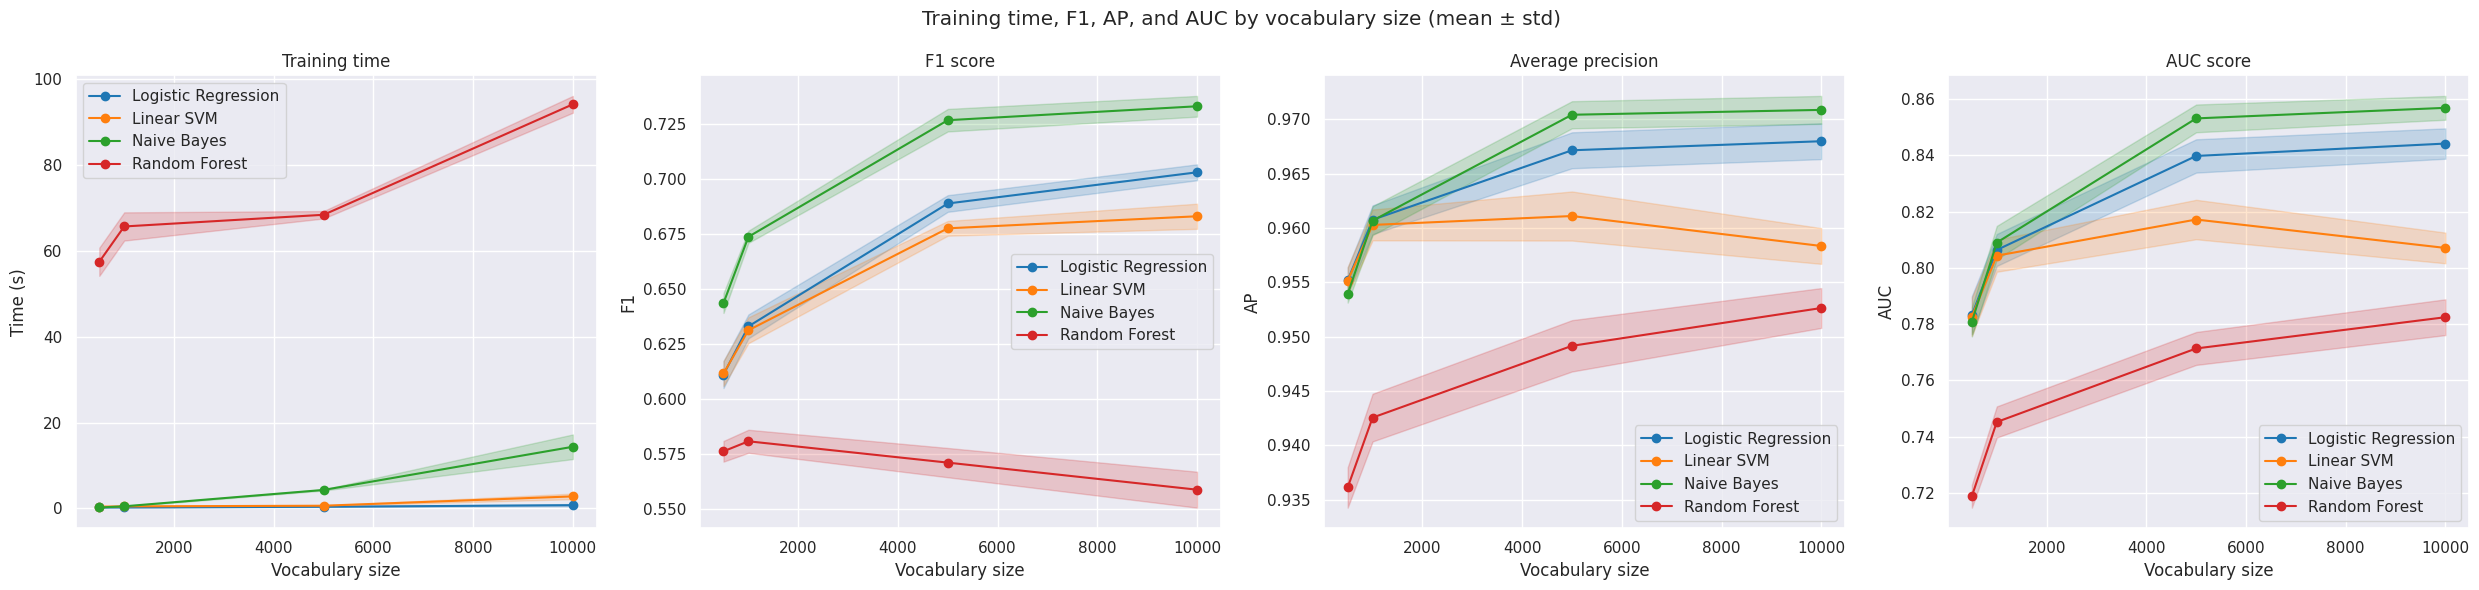

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="darkgrid")

fig, axes = plt.subplots(1, 4, figsize=(25, 6))

palette = sns.color_palette("tab10", n_colors=len(models_names))

metrics = [
    (train_time, "Training time", "Time (s)"),
    (val_f1,     "F1 score",      "F1"),
    (val_ap,     "Average precision", "AP"),
    (val_auc,    "AUC score",     "AUC"),
]

label_map = {
    "nb":         "Naive Bayes",
    "logreg":     "Logistic Regression",
    "linear_svm": "Linear SVM",
    "rf":         "Random Forest",
}

for i, (model_name, color) in enumerate(zip(models_names, palette)):
    label = label_map.get(model_name, model_name)

    data = [
        (train_time, val_f1, val_ap, val_auc)
    ]

    for ax, (metric_dict, title, ylabel) in zip(axes, metrics):
        mean_vals = np.array([np.mean(metric_dict[mf][model_name]) for mf in max_features_test])
        std_vals  = np.array([np.std(metric_dict[mf][model_name])  for mf in max_features_test])

        ax.plot(max_features_test, mean_vals, marker="o", label=label, color=color)
        ax.fill_between(
            max_features_test,
            mean_vals - std_vals,
            mean_vals + std_vals,
            alpha=0.2,
            color=color,
        )


for ax, (_, title, ylabel) in zip(axes, metrics):
    ax.set_title(title)
    ax.set_xlabel("Vocabulary size")
    ax.set_ylabel(ylabel)
    ax.legend()

plt.suptitle("Training time, F1, AP, and AUC by vocabulary size (mean ± std)")
plt.tight_layout()
plt.savefig("images/pretest/training_time_f1_ap_auc_by_vocab_size_2.pdf")
plt.show()

Replot without rerun, modifying the legend

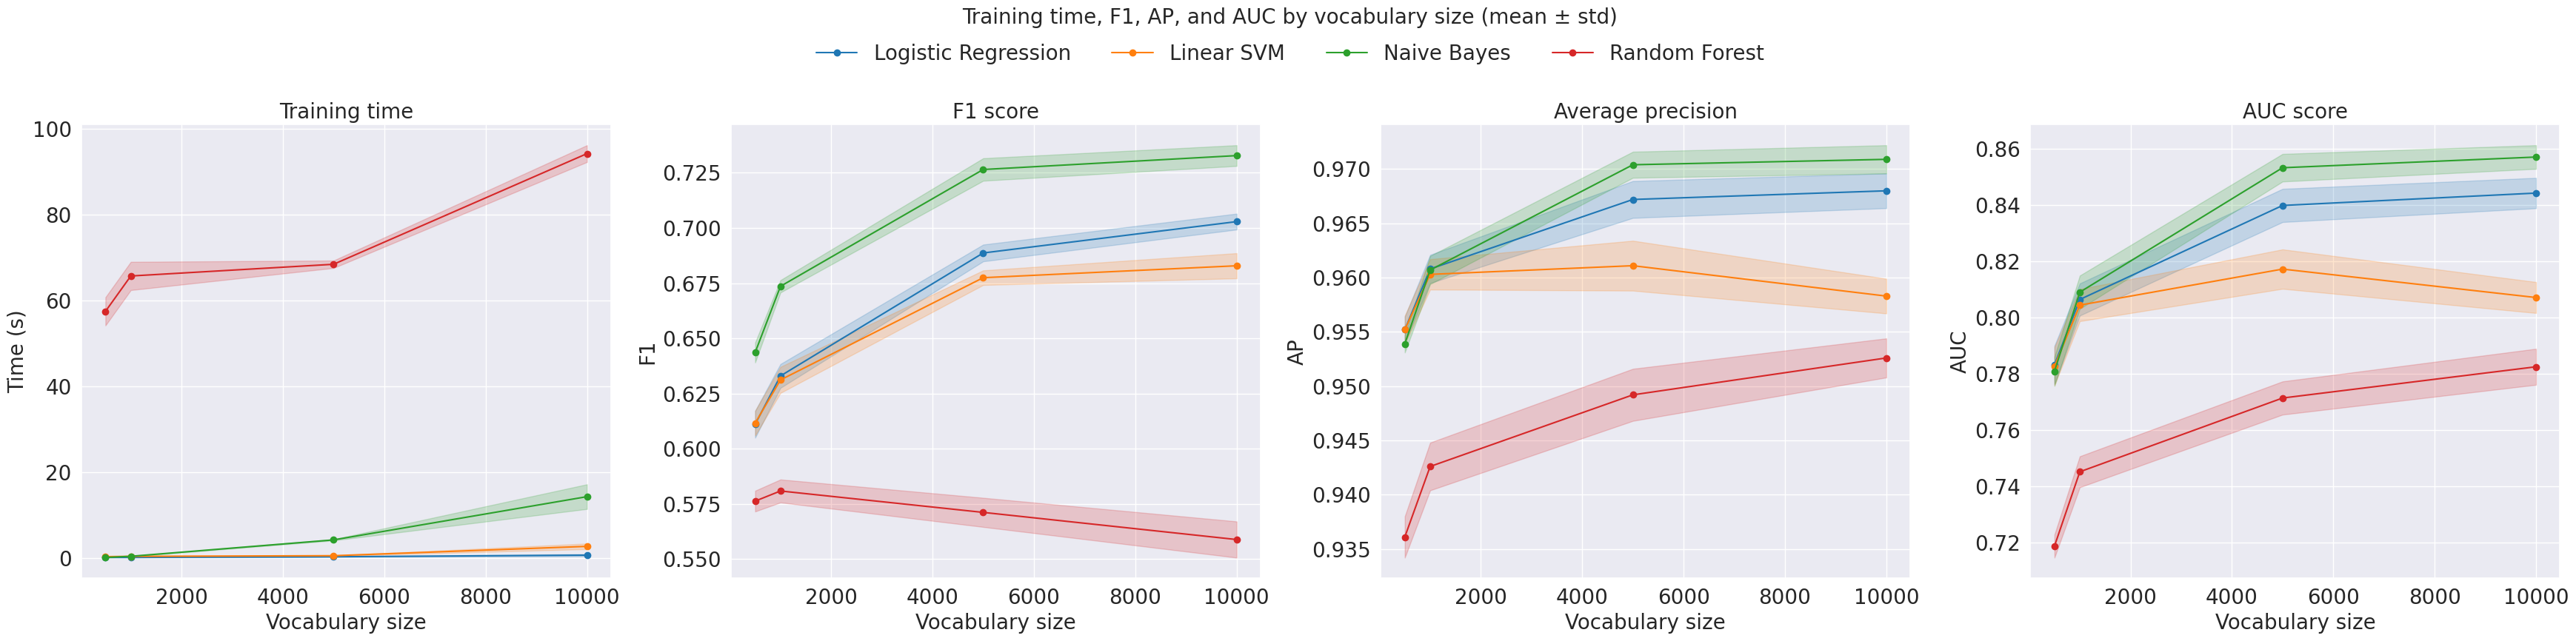

In [116]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="darkgrid")

max_features_test = [500, 1000, 5000, 10000]
models_names = ["logreg", "linear_svm", "nb", "rf"]
label_map = {
    "nb":         "Naive Bayes",
    "logreg":     "Logistic Regression",
    "linear_svm": "Linear SVM",
    "rf":         "Random Forest",
}

train_time = {
    500:   {"logreg": [0.243, 0.013], "linear_svm": [0.419, 0.028], "nb": [0.228, 0.041], "rf": [57.459, 3.278]},
    1000:  {"logreg": [0.241, 0.021], "linear_svm": [0.489, 0.031], "nb": [0.502, 0.071], "rf": [65.687, 3.287]},
    5000:  {"logreg": [0.395, 0.059], "linear_svm": [0.638, 0.036], "nb": [4.316, 0.136], "rf": [68.409, 0.869]},
    10000: {"logreg": [0.768, 0.266], "linear_svm": [2.813, 0.655], "nb": [14.371, 2.867], "rf": [94.141, 1.955]},
}
val_f1 = {
    500:   {"logreg": [0.6111, 0.0061], "linear_svm": [0.6116, 0.0056], "nb": [0.6436, 0.0045], "rf": [0.5763, 0.0047]},
    1000:  {"logreg": [0.6330, 0.0054], "linear_svm": [0.6312, 0.0059], "nb": [0.6736, 0.0028], "rf": [0.5809, 0.0052]},
    5000:  {"logreg": [0.6887, 0.0038], "linear_svm": [0.6775, 0.0033], "nb": [0.7265, 0.0051], "rf": [0.5712, 0.0066]},
    10000: {"logreg": [0.7029, 0.0036], "linear_svm": [0.6829, 0.0057], "nb": [0.7328, 0.0047], "rf": [0.5589, 0.0082]},
}
val_ap = {
    500:   {"logreg": [0.9552, 0.0012], "linear_svm": [0.9552, 0.0013], "nb": [0.9539, 0.0008], "rf": [0.9361, 0.0019]},
    1000:  {"logreg": [0.9608, 0.0013], "linear_svm": [0.9603, 0.0014], "nb": [0.9607, 0.0013], "rf": [0.9426, 0.0022]},
    5000:  {"logreg": [0.9672, 0.0017], "linear_svm": [0.9611, 0.0023], "nb": [0.9704, 0.0012], "rf": [0.9492, 0.0024]},
    10000: {"logreg": [0.9680, 0.0016], "linear_svm": [0.9583, 0.0016], "nb": [0.9709, 0.0013], "rf": [0.9526, 0.0018]},
}
val_auc = {
    500:   {"logreg": [0.7832, 0.0068], "linear_svm": [0.7827, 0.0068], "nb": [0.7809, 0.0052], "rf": [0.7188, 0.0041]},
    1000:  {"logreg": [0.8064, 0.0057], "linear_svm": [0.8044, 0.0057], "nb": [0.8090, 0.0059], "rf": [0.7452, 0.0055]},
    5000:  {"logreg": [0.8398, 0.0059], "linear_svm": [0.8172, 0.0070], "nb": [0.8532, 0.0049], "rf": [0.7714, 0.0059]},
    10000: {"logreg": [0.8442, 0.0054], "linear_svm": [0.8071, 0.0055], "nb": [0.8570, 0.0042], "rf": [0.7825, 0.0064]},
}

metrics = [
    (train_time, "Training time",       "Time (s)"),
    (val_f1,     "F1 score",            "F1"),
    (val_ap,     "Average precision",   "AP"),
    (val_auc,    "AUC score",           "AUC"),
]

palette = sns.color_palette("tab10", n_colors=len(models_names))
fig, axes = plt.subplots(1, 4, figsize=(35, 8))

for model_name, color in zip(models_names, palette):
    label = label_map.get(model_name, model_name)
    for ax, (metric_dict, title, ylabel) in zip(axes, metrics):
        mean_vals = np.array([metric_dict[mf][model_name][0] for mf in max_features_test])
        std_vals  = np.array([metric_dict[mf][model_name][1] for mf in max_features_test])
        ax.plot(max_features_test, mean_vals, marker="o", label=label, color=color)
        ax.fill_between(max_features_test,
                        mean_vals - std_vals,
                        mean_vals + std_vals,
                        alpha=0.2, color=color)

for ax, (_, title, ylabel) in zip(axes, metrics):
    ax.set_title(title, fontsize=20)
    ax.set_xlabel("Vocabulary size", fontsize=20)
    ax.set_ylabel(ylabel, fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=20)

# shared legend on top
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, 1.05), fontsize=20)

plt.suptitle("Training time, F1, AP, and AUC by vocabulary size (mean ± std)", y=1.08, fontsize=20)
plt.tight_layout()
plt.savefig("images/pretest/training_time_f1_ap_auc_by_vocab_size_3.pdf", bbox_inches="tight")
plt.show()

### 2. Cross validation vs split

In [22]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score
import numpy as np
import gc

n_runs   = 20
max_feat = 5000

# ── 1. Repeated hold-out ──────────────────────────────────────────────────────
split_ap_scores  = []
split_f1_scores  = []
split_auc_scores = []

for seed in range(n_runs):
    X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
        X_train, y_train,
        test_size=0.2,
        stratify=y_train,
        random_state=seed,
    )
    vectoriser = build_vectorizer(
        name="count",
        stop_words=final_stopwords_list,
        max_features=max_feat,
        preprocessor=prep,
    )
    X_train_vec = vectoriser.fit_transform(X_train_sub)
    X_test_vec  = vectoriser.transform(X_test_sub)

    model = LogisticRegression(solver="lbfgs", max_iter=2000)
    model.fit(X_train_vec, y_train_sub)

    y_score = model.decision_function(X_test_vec)
    y_pred  = model.predict(X_test_vec)

    split_ap_scores.append(average_precision_score(y_test_sub, y_score, pos_label=1))
    split_f1_scores.append(f1_score(y_test_sub, y_pred, average="macro"))
    split_auc_scores.append(roc_auc_score(y_test_sub, y_score))

    del vectoriser, model, X_train_vec, X_test_vec, y_score, y_pred
    gc.collect()

split_ap_scores  = np.array(split_ap_scores)
split_f1_scores  = np.array(split_f1_scores)
split_auc_scores = np.array(split_auc_scores)

print("Repeated hold-out (20 runs)")
print(f"  AP  — mean: {split_ap_scores.mean():.4f}  std: {split_ap_scores.std():.4f}  scores: {np.round(split_ap_scores, 4)}")
print(f"  F1  — mean: {split_f1_scores.mean():.4f}  std: {split_f1_scores.std():.4f}  scores: {np.round(split_f1_scores, 4)}")
print(f"  AUC — mean: {split_auc_scores.mean():.4f}  std: {split_auc_scores.std():.4f}  scores: {np.round(split_auc_scores, 4)}")

# ── 2. Stratified K-Fold CV ───────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_ap_scores  = []
cv_f1_scores  = []
cv_auc_scores = []

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X_train, y_train), start=1):
    X_train_fold = X_train[train_idx]
    y_train_fold = y_train[train_idx]
    X_test_fold  = X_train[test_idx]
    y_test_fold  = y_train[test_idx]

    vectoriser = build_vectorizer(
        name="count",
        stop_words=final_stopwords_list,
        max_features=max_feat,
        preprocessor=prep,
    )
    X_train_vec = vectoriser.fit_transform(X_train_fold)
    X_test_vec  = vectoriser.transform(X_test_fold)

    model = LogisticRegression(solver="lbfgs", max_iter=2000)
    model.fit(X_train_vec, y_train_fold)

    y_score = model.decision_function(X_test_vec)
    y_pred  = model.predict(X_test_vec)

    cv_ap_scores.append(average_precision_score(y_test_fold, y_score, pos_label=1))
    cv_f1_scores.append(f1_score(y_test_fold, y_pred, average="macro"))
    cv_auc_scores.append(roc_auc_score(y_test_fold, y_score))

    print(f"  Fold {fold_idx}/5 — AP: {cv_ap_scores[-1]:.4f}  F1: {cv_f1_scores[-1]:.4f}  AUC: {cv_auc_scores[-1]:.4f}")

    del vectoriser, model, X_train_vec, X_test_vec, y_score, y_pred
    gc.collect()

cv_ap_scores  = np.array(cv_ap_scores)
cv_f1_scores  = np.array(cv_f1_scores)
cv_auc_scores = np.array(cv_auc_scores)

print("\nStratified 5-fold CV")
print(f"  AP  — mean: {cv_ap_scores.mean():.4f}  std: {cv_ap_scores.std():.4f}  scores: {np.round(cv_ap_scores, 4)}")
print(f"  F1  — mean: {cv_f1_scores.mean():.4f}  std: {cv_f1_scores.std():.4f}  scores: {np.round(cv_f1_scores, 4)}")
print(f"  AUC — mean: {cv_auc_scores.mean():.4f}  std: {cv_auc_scores.std():.4f}  scores: {np.round(cv_auc_scores, 4)}")

Repeated hold-out (20 runs)
  AP  — mean: 0.9682  std: 0.0013  scores: [0.9706 0.9681 0.9674 0.9693 0.9707 0.9675 0.9669 0.9688 0.9667 0.9686
 0.9675 0.9691 0.9666 0.9687 0.9692 0.9675 0.9661 0.9696 0.9661 0.9693]
  F1  — mean: 0.6958  std: 0.0068  scores: [0.7062 0.6902 0.7051 0.7031 0.7055 0.6959 0.6874 0.6842 0.685  0.7026
 0.6925 0.6999 0.6944 0.6991 0.6957 0.6953 0.6881 0.6917 0.6922 0.7024]
  AUC — mean: 0.8431  std: 0.0052  scores: [0.8534 0.8407 0.8448 0.8494 0.8527 0.8391 0.84   0.8416 0.8376 0.8457
 0.8373 0.8445 0.8379 0.8469 0.8435 0.8413 0.835  0.8459 0.8365 0.8487]
  Fold 1/5 — AP: 0.9671  F1: 0.7054  AUC: 0.8404
  Fold 2/5 — AP: 0.9676  F1: 0.6948  AUC: 0.8355
  Fold 3/5 — AP: 0.9686  F1: 0.6944  AUC: 0.8446
  Fold 4/5 — AP: 0.9691  F1: 0.6989  AUC: 0.8521
  Fold 5/5 — AP: 0.9701  F1: 0.7008  AUC: 0.8511

Stratified 5-fold CV
  AP  — mean: 0.9685  std: 0.0011  scores: [0.9671 0.9676 0.9686 0.9691 0.9701]
  F1  — mean: 0.6989  std: 0.0041  scores: [0.7054 0.6948 0.6944 0.

In [8]:
# from saved:
split_ap_scores = np.array([0.9706, 0.9681, 0.9674, 0.9693, 0.9707, 0.9675, 0.9669, 0.9688, 0.9667, 0.9686,
                   0.9675, 0.9691, 0.9666, 0.9687, 0.9692, 0.9675, 0.9661, 0.9696, 0.9661, 0.9693])

split_f1_scores =  np.array([0.7062, 0.6902, 0.7051, 0.7031, 0.7055, 0.6959, 0.6874, 0.6842, 0.685, 0.7026,
                     0.6925, 0.6999, 0.6944, 0.6991, 0.6957, 0.6953, 0.6881, 0.6917, 0.6922, 0.7024])

split_auc_scores = np.array([0.8534, 0.8407, 0.8448, 0.8494, 0.8527, 0.8391, 0.84, 0.8416, 0.8376, 0.8457,
                     0.8373, 0.8445, 0.8379, 0.8469, 0.8435, 0.8413, 0.835, 0.8459, 0.8365, 0.8487])

cv_ap_scores = np.array([0.9671, 0.9676, 0.9686, 0.9691, 0.9701])

cv_f1_scores = np.array([0.7054, 0.6948, 0.6944, 0.6989, 0.7008])

cv_auc_scores = np.array([0.8404, 0.8355, 0.8446, 0.8521, 0.8511])

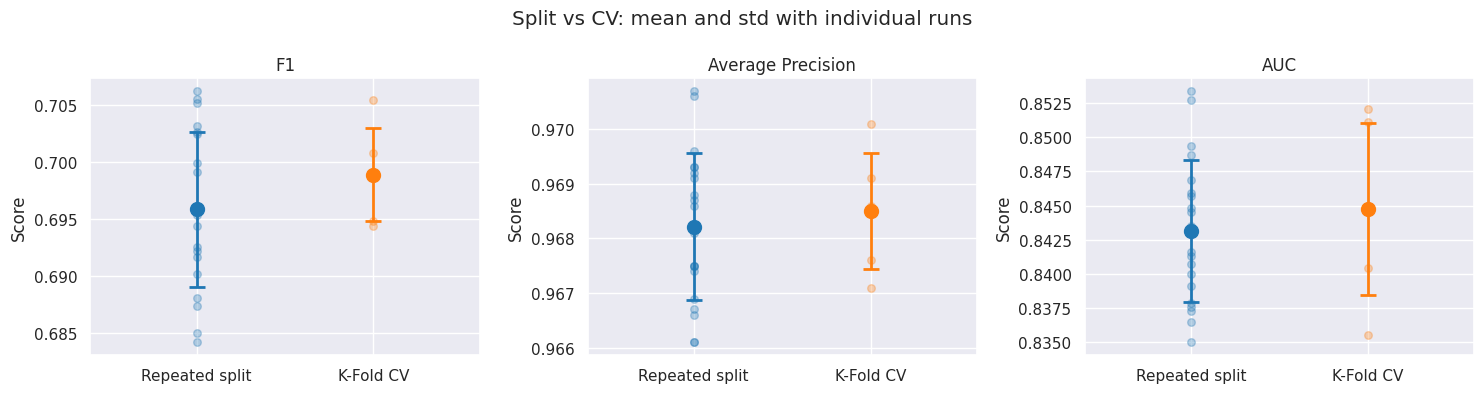

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
palette = sns.color_palette("tab10")

metrics     = ["F1", "Average Precision", "AUC"]
split_means = [split_f1_scores.mean(), split_ap_scores.mean(), split_auc_scores.mean()]
split_stds  = [split_f1_scores.std(),  split_ap_scores.std(),  split_auc_scores.std()]
cv_means    = [cv_f1_scores.mean(),    cv_ap_scores.mean(),    cv_auc_scores.mean()]
cv_stds     = [cv_f1_scores.std(),     cv_ap_scores.std(),     cv_auc_scores.std()]

score_map = {
    "F1":                (split_f1_scores,  cv_f1_scores),
    "Average Precision": (split_ap_scores,  cv_ap_scores),
    "AUC":               (split_auc_scores, cv_auc_scores),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, metric, s_mean, s_std, cv_mean, cv_std in zip(
        axes, metrics, split_means, split_stds, cv_means, cv_stds):

    split_scores, cv_scores = score_map[metric]

    ax.scatter(np.zeros(len(split_scores)), split_scores,
               color=palette[0], alpha=0.3, zorder=1, s=30)
    ax.scatter(np.ones(len(cv_scores)), cv_scores,
               color=palette[1], alpha=0.3, zorder=1, s=30)

    for x_pos, mean, std, color, label in [
        (0, s_mean,  s_std,  palette[0], "Repeated split"),
        (1, cv_mean, cv_std, palette[1], "K-Fold CV"),
    ]:
        ax.errorbar(x_pos, mean, yerr=std,
                    fmt="o", color=color, label=label,
                    markersize=10, capsize=6, capthick=2,
                    linewidth=2, zorder=2)

    ax.set_xlim(-0.6, 1.6)
    ax.set_title(metric)
    ax.set_ylabel("Score")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Repeated split", "K-Fold CV"])
    # ax.legend(loc="lower center", bbox_to_anchor=(0.5, 0.01))

plt.suptitle("Split vs CV: mean and std with individual runs")
plt.tight_layout()
plt.savefig("images/pretest/split_cv.pdf")
plt.show()

### 3. Test of different preprocessing

Here we test different preprocessing to see what is the most efficient. We will use Tfidf vectorizer and logistic regression to evaluate.
- 1. no preprocessing
- 2. lower case and no punctuation
- 3. add remove accents
- 4. add lemmatisation 
- 5. add stemming (no lemma)
- 6. no punctuation only

In [6]:
punc = set(string.punctuation + '\n\r\t')
punc.remove("'") # keep the ' for french words 
custom_punctuation = "".join(punc)

#lower case and no punctuation
prep2 = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = False, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

#add remove accents
prep3 = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = False, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = True, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )
# add lemma
prep4 = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = "lemma", # stem faster
                pos_tagging = False, # to check
                all_capital = False, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False,  # check if changes!!!!
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

# add stemming
prep5 = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = "stem", # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

# no punctuation only
prep6 = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = "stem", # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

from nltk.stem import SnowballStemmer 
import spacy, unicodedata

stopwords_no_accent = [unicodedata.normalize('NFD', text).encode('ascii', 'ignore').decode("utf-8") for text in final_stopwords_list]

stemmer = SnowballStemmer("french")
stemmed_stopwords = [stemmer.stem(word) for word in final_stopwords_list]
stemmed_stopw_no_accent = [unicodedata.normalize('NFD', text).encode('ascii', 'ignore').decode("utf-8") for text in stemmed_stopwords]


nlp_lem = spacy.load("fr_core_news_sm", disable=["parser", "ner"])
lemma_stopwords = []

for word in final_stopwords_list:
    doc = nlp_lem(word)
    for token in doc:
        lemma_stopwords.append(token.lemma_.lower())

lemma_stopwords_no_accent = [unicodedata.normalize('NFD', text).encode('ascii', 'ignore').decode("utf-8") for text in lemma_stopwords]

In [ ]:
# plot with prep6
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
import pandas as pd
import gc

preprocessors = {
    "prep1_raw":[None, None,"count"],
    "prep2_lower+punct":[prep2, final_stopwords_list,"count"],
    "prep3_+accent_removal":[prep3, stopwords_no_accent,"count"],
    "prep4_+lemmatisation": [prep4, lemma_stopwords_no_accent,"count"],
    "prep5_+stemming":[prep5, stemmed_stopw_no_accent,  "count"],
    "prep6_+no_punctuation":[prep6, final_stopwords_list,"count"],
    "prep1_raw_tfidf":[None, None,"tfidf"],
    "prep2_lower+punct_tfidf":[prep2, final_stopwords_list,"tfidf"],
    "prep3_+accent_removal_tfidf":[prep3, stopwords_no_accent,"tfidf"],
    "prep4_+lemmatisation_tfidf": [prep4, lemma_stopwords_no_accent,"tfidf"],
    "prep5_+stemming_tfidf":[prep5, stemmed_stopw_no_accent,"tfidf"],
    "prep6_+no_punctuation_tfidf":[prep6, final_stopwords_list,"tfidf"]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, el in preprocessors.items():
    preproc, stop_w, vect_type = el

    fold_metrics = {"ap": [], "auc": [], "f1": []}

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
        y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

        vectoriser = build_vectorizer(
            name=vect_type,
            stop_words=stop_w,
            max_features=5000,
            **({"preprocessor": preproc} if preproc is not None else {})
        )

        X_train_vec = vectoriser.fit_transform(X_train_fold)
        X_val_vec   = vectoriser.transform(X_val_fold)

        model = LogisticRegression(solver="lbfgs", max_iter=2000)
        model.fit(X_train_vec, y_train_fold)

        y_val_score = model.decision_function(X_val_vec)
        y_val_pred  = model.predict(X_val_vec)

        fold_metrics["ap"].append(average_precision_score(y_val_fold, y_val_score))
        fold_metrics["auc"].append(roc_auc_score(y_val_fold, y_val_score))
        fold_metrics["f1"].append(f1_score(y_val_fold, y_val_pred, average="macro"))

        del vectoriser, model, X_train_vec, X_val_vec, y_val_score, y_val_pred
        gc.collect()

    results.append({
        "preprocessor": name,
        "vect_type":    vect_type,
        "mean_ap":      np.mean(fold_metrics["ap"]),
        "std_ap":       np.std(fold_metrics["ap"]),
        "mean_auc":     np.mean(fold_metrics["auc"]),
        "std_auc":      np.std(fold_metrics["auc"]),
        "mean_f1":      np.mean(fold_metrics["f1"]),
        "std_f1":       np.std(fold_metrics["f1"]),
    })

    print(f"{name}")
    print(f"  AP  : {np.mean(fold_metrics['ap']):.4f} ± {np.std(fold_metrics['ap']):.4f}")
    print(f"  AUC : {np.mean(fold_metrics['auc']):.4f} ± {np.std(fold_metrics['auc']):.4f}")
    print(f"  F1  : {np.mean(fold_metrics['f1']):.4f} ± {np.std(fold_metrics['f1']):.4f}")
    print()

# --- Split into two DataFrames ---
df_all   = pd.DataFrame(results)
df_count = df_all[df_all["vect_type"] == "count"].drop(columns="vect_type").reset_index(drop=True)
df_tfidf = df_all[df_all["vect_type"] == "tfidf"].drop(columns="vect_type").reset_index(drop=True)

print("=== COUNT ===")
print(df_count.to_string(index=False))
print("\n=== TFIDF ===")
print(df_tfidf.to_string(index=False))

prep1_raw
  AP  : 0.6278 ± 0.0140
  AUC : 0.8715 ± 0.0073
  F1  : 0.7400 ± 0.0043

prep2_lower+punct
  AP  : 0.5595 ± 0.0152
  AUC : 0.8434 ± 0.0099
  F1  : 0.7043 ± 0.0031

prep3_+accent_removal
  AP  : 0.5540 ± 0.0162
  AUC : 0.8418 ± 0.0105
  F1  : 0.7024 ± 0.0042



/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['etier', 'fumer', 'luir', 'être'] not in stop_words.
  warnings.warn(
/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['etier', 'fumer', 'luir', 'être'] not in stop_words.
  warnings.warn(
/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['etier', 'fumer', 'luir', 'être'] not in stop_words.
  warnings.warn(
/

prep4_+lemmatisation
  AP  : 0.5801 ± 0.0173
  AUC : 0.8540 ± 0.0073
  F1  : 0.7102 ± 0.0077

prep5_+stemming
  AP  : 0.5692 ± 0.0152
  AUC : 0.8512 ± 0.0088
  F1  : 0.7028 ± 0.0061



/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aur', 'aurion', 'auron', 'avi', 'avion', 'avon', 'ayon', 'dan', 'euss', 'eussion', 'eûm', 'fuss', 'fussion', 'fûm', 'mêm', 'notr', 'ser', 'serion', 'seron', 'somm', 'soyon', 'votr', 'éti', 'étion', 'ête'] not in stop_words.
  warnings.warn(
/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aur', 'aurion', 'auron', 'avi', 'avion', 'avon', 'ayon', 'dan', 'euss', 'eussion', 'eûm', 'fuss', 'fussion', 'fûm', 'mêm', 'notr', 'ser', 'serion', 'seron', 'somm', 'soyon', 'votr', 'éti', 'étion', 'ête'] not in stop_words.
  warni

prep6_+no_punctuation
  AP  : 0.5617 ± 0.0141
  AUC : 0.8554 ± 0.0083
  F1  : 0.6500 ± 0.0046

prep1_raw_tfidf
  AP  : 0.6177 ± 0.0107
  AUC : 0.8756 ± 0.0059
  F1  : 0.6892 ± 0.0080

prep2_lower+punct_tfidf
  AP  : 0.5511 ± 0.0149
  AUC : 0.8491 ± 0.0095
  F1  : 0.6388 ± 0.0039

prep3_+accent_removal_tfidf
  AP  : 0.5488 ± 0.0160
  AUC : 0.8475 ± 0.0101
  F1  : 0.6346 ± 0.0054



/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['etier', 'fumer', 'luir', 'être'] not in stop_words.
  warnings.warn(
/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['etier', 'fumer', 'luir', 'être'] not in stop_words.
  warnings.warn(
/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['etier', 'fumer', 'luir', 'être'] not in stop_words.
  warnings.warn(
/

prep4_+lemmatisation_tfidf
  AP  : 0.5653 ± 0.0205
  AUC : 0.8576 ± 0.0076
  F1  : 0.6535 ± 0.0051

prep5_+stemming_tfidf
  AP  : 0.5603 ± 0.0164
  AUC : 0.8544 ± 0.0091
  F1  : 0.6493 ± 0.0031

=== COUNT ===
         preprocessor  mean_ap   std_ap  mean_auc  std_auc  mean_f1   std_f1
            prep1_raw 0.627813 0.013983  0.871533 0.007287 0.740040 0.004341
    prep2_lower+punct 0.559531 0.015213  0.843359 0.009883 0.704257 0.003123
prep3_+accent_removal 0.554041 0.016160  0.841819 0.010466 0.702432 0.004197
 prep4_+lemmatisation 0.580062 0.017329  0.854001 0.007317 0.710249 0.007697
      prep5_+stemming 0.569189 0.015155  0.851160 0.008820 0.702755 0.006056

=== TFIDF ===
               preprocessor  mean_ap   std_ap  mean_auc  std_auc  mean_f1   std_f1
      prep6_+no_punctuation 0.561653 0.014076  0.855374 0.008327 0.649969 0.004619
            prep1_raw_tfidf 0.617675 0.010678  0.875596 0.005907 0.689157 0.007958
    prep2_lower+punct_tfidf 0.551073 0.014904  0.849092 0.009511 

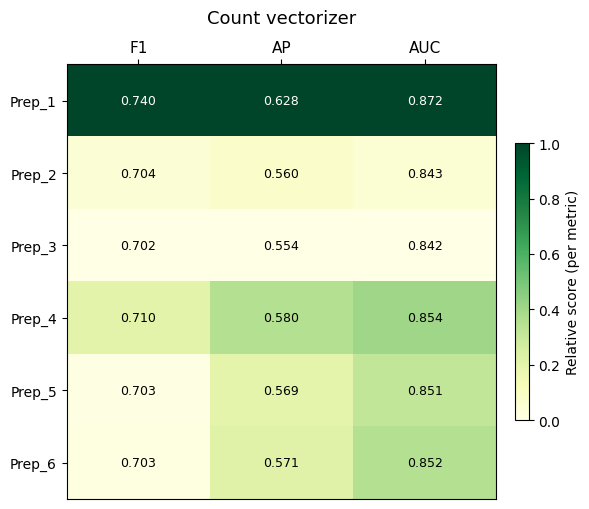

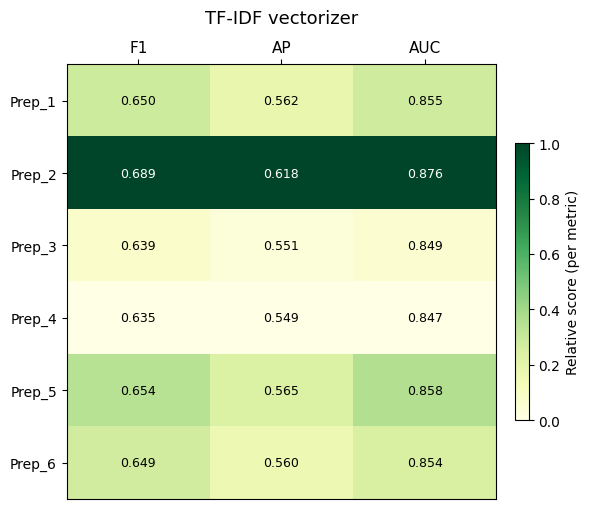

In [30]:
import matplotlib.pyplot as plt
import numpy as np

def plot_heatmap(df, title, filename=None):
    metrics = ["mean_f1", "mean_ap", "mean_auc"]
    metric_labels = ["F1", "AP", "AUC"]
    prep_names = df["preprocessor"].tolist()
    
    # --- RAW values (for annotations) ---
    raw_data = df[metrics].values.astype(float)

    # --- NORMALIZED values (for colors only, per column) ---
    col_min = raw_data.min(axis=0)
    col_max = raw_data.max(axis=0)
    norm_data = (raw_data - col_min) / (col_max - col_min + 1e-8)

    fig, ax = plt.subplots(figsize=(6, len(prep_names) * 0.7 + 1))

    # Use normalized data for heatmap colors
    im = ax.imshow(norm_data, aspect="auto", cmap="YlGn", vmin=0, vmax=1)

    # Axes labels
    ax.grid(False)
    ax.set_xticks(range(len(metric_labels)))
    ax.set_xticklabels(metric_labels, fontsize=11)
    ax.set_yticks(range(len(prep_names)))
    ax.set_yticklabels([f"Prep_{i+1}" for i in range(len(prep_names))], fontsize=10)

    # Annotate each cell with TRUE values
    std_cols = ["std_f1", "std_ap", "std_auc"]
    for i in range(len(prep_names)):
        for j, (metric, std_col) in enumerate(zip(metrics, std_cols)):
            mean_val = raw_data[i, j]  
            std_val  = df.iloc[i][std_col]

            text = f"{mean_val:.3f}"

            # Use normalized value for background color
            norm_val = norm_data[i, j]
            bg_color = im.cmap(im.norm(norm_val))
            brightness = 0.299*bg_color[0] + 0.587*bg_color[1] + 0.114*bg_color[2]
            txt_color = "black" if brightness > 0.5 else "white"

            ax.text(j, i, text, ha="center", va="center", fontsize=9, color=txt_color)

    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04,
                 label="Relative score (per metric)")
    
    ax.set_title(title, fontsize=13, pad=12)
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")

    plt.tight_layout()
    if filename:
        plt.savefig(filename)
    plt.show()

plot_heatmap(df_count, "Count vectorizer", "images/pretest/count_heatmap_prep.pdf")
plot_heatmap(df_tfidf, "TF-IDF vectorizer", "images/pretest/tfidf_heatmap_prep.pdf")

In [20]:
df_count

,preprocessor,mean_ap,std_ap,mean_auc,std_auc,mean_f1,std_f1
0,prep1_raw,0.627813,0.013983,0.871533,0.007287,0.740040,0.004341
1,prep2_lower+punct,0.559531,0.015213,0.843359,0.009883,0.704257,0.003123
2,prep3_+accent_removal,0.554041,0.016160,0.841819,0.010466,0.702432,0.004197
3,prep4_+lemmatisation,0.580062,0.017329,0.854001,0.007317,0.710249,0.007697
4,prep5_+stemming,0.569189,0.015155,0.851160,0.008820,0.702755,0.006056


### 4. Test with n-grams

In [7]:
prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

In [11]:
# this time with cv on the train 
import time
import gc
import numpy as np
from sklearn.metrics import f1_score, average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold

In [ ]:
# max featu 5000 ...
# with cross validation

ranges_ngram = [(1,1), (1,2), (2,2), (1,3), (2,3), (3,3)]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for t in ranges_ngram:
    f1s, aps, aucs = [], [], []

    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        vectoriser = build_vectorizer(
            name="count",
            stop_words=final_stopwords_list,
            max_features=5000,
            ngram_range=t,
            preprocessor=prep
        )

        X_tr_vec  = vectoriser.fit_transform(X_tr)
        X_val_vec = vectoriser.transform(X_val)

        model = LogisticRegression(solver="lbfgs", max_iter=2000)
        model.fit(X_tr_vec, y_tr)

        y_val_score = model.decision_function(X_val_vec)
        y_val_pred  = model.predict(X_val_vec)

        f1s.append(f1_score(y_val, y_val_pred, average='macro'))
        aps.append(average_precision_score(y_val, y_val_score))
        aucs.append(roc_auc_score(y_val, y_val_score))

        del vectoriser, model, X_tr_vec, X_val_vec
        gc.collect()

    results.append({
        "ngram_range": t,
        "mean_f1":  np.mean(f1s),  "std_f1":  np.std(f1s),
        "mean_ap":  np.mean(aps),  "std_ap":  np.std(aps),
        "mean_auc": np.mean(aucs), "std_auc": np.std(aucs),
    })

    print(f"n-gram range: {t}")
    print(f"  F1 : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"  AP : {np.mean(aps):.4f} ± {np.std(aps):.4f}")
    print(f"  AUC: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")


n-gram range: (1, 1)
  F1 : 0.7065 ± 0.0030
  AP : 0.5602 ± 0.0153
  AUC: 0.8435 ± 0.0095
n-gram range: (1, 2)
  F1 : 0.7058 ± 0.0050
  AP : 0.5671 ± 0.0141
  AUC: 0.8469 ± 0.0073
n-gram range: (2, 2)
  F1 : 0.5888 ± 0.0069
  AP : 0.3971 ± 0.0064
  AUC: 0.7519 ± 0.0058
n-gram range: (1, 3)
  F1 : 0.7061 ± 0.0051
  AP : 0.5677 ± 0.0137
  AUC: 0.8470 ± 0.0073
n-gram range: (2, 3)
  F1 : 0.5919 ± 0.0062
  AP : 0.3967 ± 0.0073
  AUC: 0.7508 ± 0.0057
n-gram range: (3, 3)
  F1 : 0.4849 ± 0.0040
  AP : 0.1928 ± 0.0044
  AUC: 0.5836 ± 0.0032


NameError: name 'pd' is not defined

In [15]:
import pandas as pd
import seaborn as sns

df_ngram = pd.DataFrame(results)
print(df_ngram.to_string(index=False))

ngram_range  mean_f1   std_f1  mean_ap   std_ap  mean_auc  std_auc
     (1, 1) 0.706478 0.002964 0.560152 0.015325  0.843461 0.009493
     (1, 2) 0.705806 0.004992 0.567105 0.014058  0.846896 0.007303
     (2, 2) 0.588764 0.006949 0.397124 0.006358  0.751874 0.005768
     (1, 3) 0.706131 0.005109 0.567712 0.013679  0.847039 0.007315
     (2, 3) 0.591895 0.006226 0.396663 0.007335  0.750803 0.005712
     (3, 3) 0.484886 0.003961 0.192769 0.004404  0.583554 0.003238


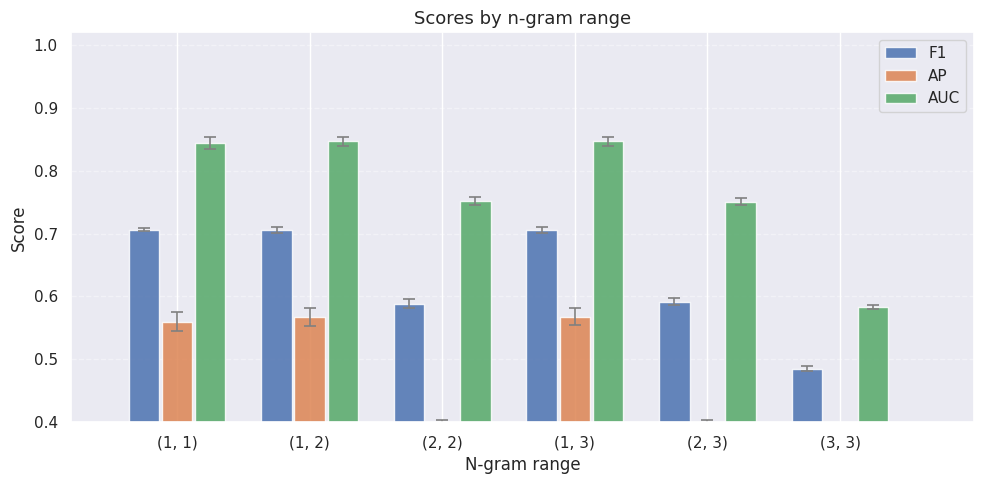

In [19]:
means = {
    'F1':  df_ngram['mean_f1'].tolist(),
    'AP':  df_ngram['mean_ap'].tolist(),
    'AUC': df_ngram['mean_auc'].tolist(),
}
stds = {
    'F1':  df_ngram['std_f1'].tolist(),
    'AP':  df_ngram['std_ap'].tolist(),
    'AUC': df_ngram['std_auc'].tolist(),
}
labels = df_ngram['ngram_range'].astype(str).tolist()

colors = {'F1': sns.color_palette()[0], 'AP': sns.color_palette()[1], 'AUC': sns.color_palette()[2]}

x = np.arange(len(labels))
n_metrics = len(means)
width = 0.25
offsets = [-width, 0, width]

fig, ax = plt.subplots(figsize=(10, 5))
sns.set_theme(style="darkgrid")

for (metric, color), offset in zip([(m, colors[m]) for m in means], offsets):
    bars = ax.bar(x + offset, means[metric], width=width - 0.02,
                  yerr=stds[metric], capsize=4,
                  label=metric, color=color, alpha=0.85,
                  error_kw=dict(elinewidth=1.2, ecolor='gray', capthick=1.2))

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('N-gram range', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Scores by n-gram range', fontsize=13, fontweight='medium')
ax.set_ylim(0.4, 1.02)
ax.set_xlim(-0.8, len(labels) + 0.010)
ax.legend(loc="upper right")
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('images/pretest/pres_ngram_metrics.pdf')
plt.show()

We verify that we do have bigrams and trigrams for n-gram range similar to unigram

In [20]:
# check unig or big after countvect
vectoriser = build_vectorizer(
            name="count",
            stop_words=final_stopwords_list,
            max_features=5000,
            ngram_range=(1,1),
            preprocessor=prep
        )

X_tr_vec  = vectoriser.fit_transform(X_train)        
vectoriser.get_feature_names_out()

array(['000', '10', '100', ..., 'être', 'êtres', 'île'],
      shape=(5000,), dtype=object)

In [21]:
[i for i in vectoriser.get_feature_names_out() if len(i.split()) > 1]

[]

In [22]:
vectoriser = build_vectorizer(
            name="count",
            stop_words=final_stopwords_list,
            max_features=5000,
            ngram_range=(1,2),
            preprocessor=prep
        )

X_tr_vec  = vectoriser.fit_transform(X_tr)

In [25]:
len([i for i in vectoriser.get_feature_names_out() if len(i.split()) > 1]), len(vectoriser.get_feature_names_out())

(1129, 5000)

In [26]:
vectoriser = build_vectorizer(
            name="count",
            stop_words=final_stopwords_list,
            max_features=5000,
            ngram_range=(1,3),
            preprocessor=prep
        )

X_tr_vec  = vectoriser.fit_transform(X_tr)

In [27]:
len([i for i in vectoriser.get_feature_names_out() if len(i.split()) > 1]), len(vectoriser.get_feature_names_out())

(1194, 5000)

In [28]:
len([i for i in vectoriser.get_feature_names_out() if len(i.split()) > 2]), len(vectoriser.get_feature_names_out())

(76, 5000)

### 5. Vector size 
- word2vec,fastext, doc2vec on trained data, different size

In [8]:
def stopwords_rmv(text, stopwords=final_stopwords_list):
    return " ".join([word for word in text.split() if word not in stopwords])


In [ ]:
# import the 3 models, run them
from gensim.models import Word2Vec, FastText
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

# ── helpers ──────────────────────────────────────────────────────────────────

def mean_embed_wv(texts, model):
    """Word2Vec / FastText: mean pool over known words."""
    vecs = []
    for text in texts:
        words = text.split()
        ws = [model.wv[w] for w in words if w in model.wv]
        vecs.append(np.mean(ws, axis=0) if ws else np.zeros(model.vector_size))
    return np.array(vecs)

def embed_doc2vec(texts, model):
    """Doc2Vec: infer one vector per document."""
    return np.array([model.infer_vector(t.split()) for t in texts])

def run_cv(X, y, n_splits=5):
    """Scale + LR inside a pipeline, return mean CV metrics."""
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(solver="lbfgs", max_iter=2000))
    ])
    scores = cross_validate(pipe, X, y, cv=n_splits,
                            scoring=["f1_macro", "roc_auc",
                                     "average_precision",
                                     "precision_macro", "recall_macro"])
    return {
        "F1":            scores["test_f1_macro"].mean(),
        "F1_std":        scores["test_f1_macro"].std(),
        "AUC":           scores["test_roc_auc"].mean(),
        "AUC_std":       scores["test_roc_auc"].std(),
        "AvgPrec":       scores["test_average_precision"].mean(),
        "AvgPrec_std":   scores["test_average_precision"].std(),
        "Precision":     scores["test_precision_macro"].mean(),
        "Precision_std": scores["test_precision_macro"].std(),
        "Recall":        scores["test_recall_macro"].mean(),
        "Recall_std":    scores["test_recall_macro"].std(),
    }

# ── preprocessing (reuse your existing prep + stopword removal) ───────────────

all_texts = [stopwords_rmv(prep.process(t)) for t in X_train]   # full dataset
all_texts_tok = [t.split() for t in all_texts]                   # tokenized

# ── experiment loop ───────────────────────────────────────────────────────────

SIZES   = [100, 200, 300]
RESULTS = []

for size in SIZES:
    print(f"\n{'='*40}\nVector size: {size}\n{'='*40}")

    # ── Word2Vec (skip-gram) ──────────────────────────────────────────────────
    w2v = Word2Vec(sentences=all_texts_tok, vector_size=size, window=5,
                   min_count=5, sg=1, epochs=5, workers=3)
    X_w2v = mean_embed_wv(all_texts, w2v)
    m = run_cv(X_w2v, y_train)
    RESULTS.append({"model": "Word2Vec", "size": size, **m})
    print(f"Word2Vec  {size}d : F1={m['F1']:.4f}  AUC={m['AUC']:.4f}")

    # ── FastText (skip-gram) ──────────────────────────────────────────────────
    ft = FastText(sentences=all_texts_tok, vector_size=size, window=5,
                  min_count=1, sg=1, epochs=5, workers=3)
    X_ft = mean_embed_wv(all_texts, ft)
    m = run_cv(X_ft, y_train)
    RESULTS.append({"model": "FastText", "size": size, **m})
    print(f"FastText  {size}d : F1={m['F1']:.4f}  AUC={m['AUC']:.4f}")

    # ── Doc2Vec (PV-DBOW, skip-gram equivalent) ───────────────────────────────
    tagged = [TaggedDocument(t.split(), [i]) for i, t in enumerate(all_texts)]
    d2v = Doc2Vec(tagged, vector_size=size, window=5,
                  min_count=1, dm=0, epochs=20, workers=4)
    X_d2v = embed_doc2vec(all_texts, d2v)
    m = run_cv(X_d2v, y_train)
    RESULTS.append({"model": "Doc2Vec", "size": size, **m})
    print(f"Doc2Vec   {size}d : F1={m['F1']:.4f}  AUC={m['AUC']:.4f}")

# ── collect ───────────────────────────────────────────────────────────────────

df_results = pd.DataFrame(RESULTS)
print("\n", df_results.to_string(index=False))



Vector size: 100
Word2Vec  100d → F1=0.5362  AUC=0.7784
FastText  100d → F1=0.5386  AUC=0.7798
Doc2Vec   100d → F1=0.5915  AUC=0.7726

Vector size: 200
Word2Vec  200d → F1=0.5545  AUC=0.7942
FastText  200d → F1=0.5526  AUC=0.7938
Doc2Vec   200d → F1=0.6146  AUC=0.7853

Vector size: 300
Word2Vec  300d → F1=0.5590  AUC=0.7995
FastText  300d → F1=0.5523  AUC=0.7943
Doc2Vec   300d → F1=0.6296  AUC=0.7933

    model  size       F1      AUC  AvgPrec  Precision   Recall
Word2Vec   100 0.536240 0.778371 0.953166   0.675177 0.535386
FastText   100 0.538556 0.779754 0.953939   0.682777 0.536859
 Doc2Vec   100 0.591543 0.772595 0.950942   0.770395 0.570870
Word2Vec   200 0.554514 0.794205 0.957260   0.685309 0.546653
FastText   200 0.552561 0.793843 0.956835   0.690404 0.545477
 Doc2Vec   200 0.614636 0.785280 0.953573   0.773812 0.587358
Word2Vec   300 0.559002 0.799462 0.958088   0.684944 0.549566
FastText   300 0.552267 0.794349 0.956982   0.688675 0.545267
 Doc2Vec   300 0.629583 0.793250 0.

In [78]:
# import the 3 models, run them
from gensim.models import Word2Vec, FastText
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

# ── helpers ──────────────────────────────────────────────────────────────────

def mean_embed_wv(texts, model):
    """Word2Vec / FastText: mean pool over known words."""
    vecs = []
    for text in texts:
        words = text.split()
        ws = [model.wv[w] for w in words if w in model.wv]
        vecs.append(np.mean(ws, axis=0) if ws else np.zeros(model.vector_size))
    return np.array(vecs)

def embed_doc2vec(texts, model):
    """Doc2Vec: infer one vector per document."""
    return np.array([model.infer_vector(t.split()) for t in texts])

def run_cv(X, y, n_splits=5):
    """Scale + LR inside a pipeline, return mean CV metrics."""
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(solver="lbfgs", max_iter=2000))
    ])
    scores = cross_validate(pipe, X, y, cv=n_splits,
                            scoring=["f1_macro", "roc_auc",
                                     "average_precision"])
    return {
        "F1":            scores["test_f1_macro"].mean(),
        "F1_std":        scores["test_f1_macro"].std(),
        "AUC":           scores["test_roc_auc"].mean(),
        "AUC_std":       scores["test_roc_auc"].std(),
        "AvgPrec":       scores["test_average_precision"].mean(),
        "AvgPrec_std":   scores["test_average_precision"].std(),
    }

# ── preprocessing (reuse your existing prep + stopword removal) ───────────────

all_texts = [stopwords_rmv(prep.process(t)) for t in X_train]   # full dataset
all_texts_tok = [t.split() for t in all_texts]                   # tokenized

# ── experiment loop ───────────────────────────────────────────────────────────

SIZES   = [100, 200, 300]
RESULTS = []

for size in SIZES:
    print(f"\n{'='*40}\nVector size: {size}\n{'='*40}")

    # ── Word2Vec (skip-gram) ──────────────────────────────────────────────────
    w2v = Word2Vec(sentences=all_texts_tok, vector_size=size, window=5,
                   min_count=5, sg=1, epochs=5, workers=3)
    X_w2v = mean_embed_wv(all_texts, w2v)
    m = run_cv(X_w2v, y_train)
    RESULTS.append({"model": "Word2Vec", "size": size, **m})
    print(f"Word2Vec  {size}d : F1={m['F1']:.4f}  AUC={m['AUC']:.4f}")

    # ── FastText (skip-gram) ──────────────────────────────────────────────────
    ft = FastText(sentences=all_texts_tok, vector_size=size, window=5,
                  min_count=1, sg=1, epochs=5, workers=3)
    X_ft = mean_embed_wv(all_texts, ft)
    m = run_cv(X_ft, y_train)
    RESULTS.append({"model": "FastText", "size": size, **m})
    print(f"FastText  {size}d : F1={m['F1']:.4f}  AUC={m['AUC']:.4f}")

    # ── Doc2Vec (PV-DBOW, skip-gram equivalent) ───────────────────────────────
    tagged = [TaggedDocument(t.split(), [i]) for i, t in enumerate(all_texts)]
    d2v = Doc2Vec(tagged, vector_size=size, window=5,
                  min_count=1, dm=0, epochs=20, workers=4)
    X_d2v = embed_doc2vec(all_texts, d2v)
    m = run_cv(X_d2v, y_train)
    RESULTS.append({"model": "Doc2Vec", "size": size, **m})
    print(f"Doc2Vec   {size}d : F1={m['F1']:.4f}  AUC={m['AUC']:.4f}")

# ── collect ───────────────────────────────────────────────────────────────────

df_results = pd.DataFrame(RESULTS)
print("\n", df_results.to_string(index=False))



Vector size: 100
Word2Vec  100d : F1=0.5346  AUC=0.7795
FastText  100d : F1=0.5356  AUC=0.7811
Doc2Vec   100d : F1=0.5871  AUC=0.7705

Vector size: 200
Word2Vec  200d : F1=0.5524  AUC=0.7935
FastText  200d : F1=0.5481  AUC=0.7912
Doc2Vec   200d : F1=0.6182  AUC=0.7882

Vector size: 300
Word2Vec  300d : F1=0.5597  AUC=0.7998
FastText  300d : F1=0.5516  AUC=0.7933
Doc2Vec   300d : F1=0.6279  AUC=0.7952

    model  size       F1   F1_std      AUC  AUC_std  AvgPrec  AvgPrec_std
Word2Vec   100 0.534580 0.002565 0.779522 0.007562 0.953842     0.001654
FastText   100 0.535577 0.007343 0.781126 0.006854 0.954095     0.001372
 Doc2Vec   100 0.587080 0.003875 0.770538 0.004746 0.950129     0.001525
Word2Vec   200 0.552380 0.004586 0.793519 0.006125 0.956855     0.001238
FastText   200 0.548057 0.007086 0.791247 0.006871 0.956080     0.002276
 Doc2Vec   200 0.618166 0.004689 0.788200 0.002961 0.954710     0.000711
Word2Vec   300 0.559664 0.005795 0.799769 0.003173 0.958117     0.000842
FastText 

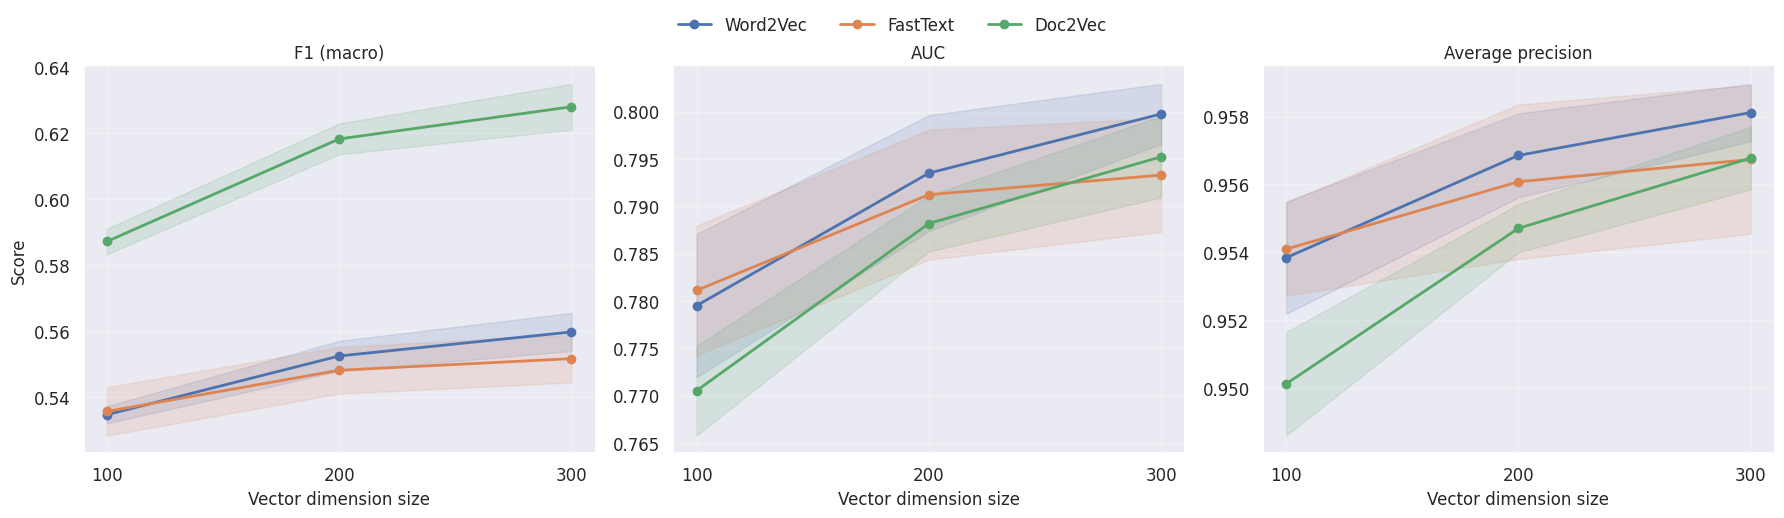

In [120]:
import matplotlib.pyplot as plt

METRICS = ["F1",        "AUC",  "AvgPrec"]
LABELS  = ["F1 (macro)","AUC",  "Average precision"]
MODELS  = ["Word2Vec", "FastText", "Doc2Vec"]
COLORS  = {"Word2Vec": sns.color_palette()[0], "FastText": sns.color_palette()[1], "Doc2Vec":sns.color_palette()[2]}
SIZES   = [100, 200, 300]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, label in zip(axes, METRICS, LABELS):
    for model in MODELS:
        subset = df_results[df_results["model"] == model].sort_values("size")
        ax.plot(subset["size"], subset[metric], marker="o",
                color=COLORS[model], linewidth=2, label=model)
        ax.fill_between(subset["size"],
                        subset[metric] - subset[f"{metric}_std"],
                        subset[metric] + subset[f"{metric}_std"],
                        color=COLORS[model], alpha=0.15)
    ax.set_title(label, fontsize=12)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlabel("Vector dimension size", fontsize=12)
    ax.set_xticks(SIZES)
    ax.grid(True, alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=12)


axes[0].set_ylabel("Score", fontsize=12)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False,
           bbox_to_anchor=(0.5, 1.05), fontsize=12)

# # colored text labels on the right, outside the last subplot
# for i, model in enumerate(MODELS):
#     fig.text(1.01, 0.75 - i * 0.15, model,
#              color=COLORS[model],
#              fontsize=10, fontweight="500",
#              va="center", transform=axes[-1].transAxes)

plt.subplots_adjust(top=0.85)
plt.tight_layout()
plt.savefig("images/pretest/vectors_size_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.5 Embedding sizes (ran ppti)

python file embeddings_comp.py

In [32]:
import json

with open("res_files_saved/embed_size_cv.json") as json_file:
    json_data_emb = json.load(json_file)

In [33]:
json_data_emb[0].keys()

dict_keys(['dim', 'encode_total_s', 'eval_s', 'F1', 'F1_std', 'AUC', 'AUC_std', 'AvgPrec', 'AvgPrec_std', 'Precision', 'Precision_std', 'Recall', 'Recall_std', 'f1', 'auc', 'avg_prec', 'precision', 'recall'])

In [37]:
dims = [r['dim'] for r in json_data_emb][:-1]
dims # computed dim 1024 but corresponds to 512

[128, 256, 512, 768]

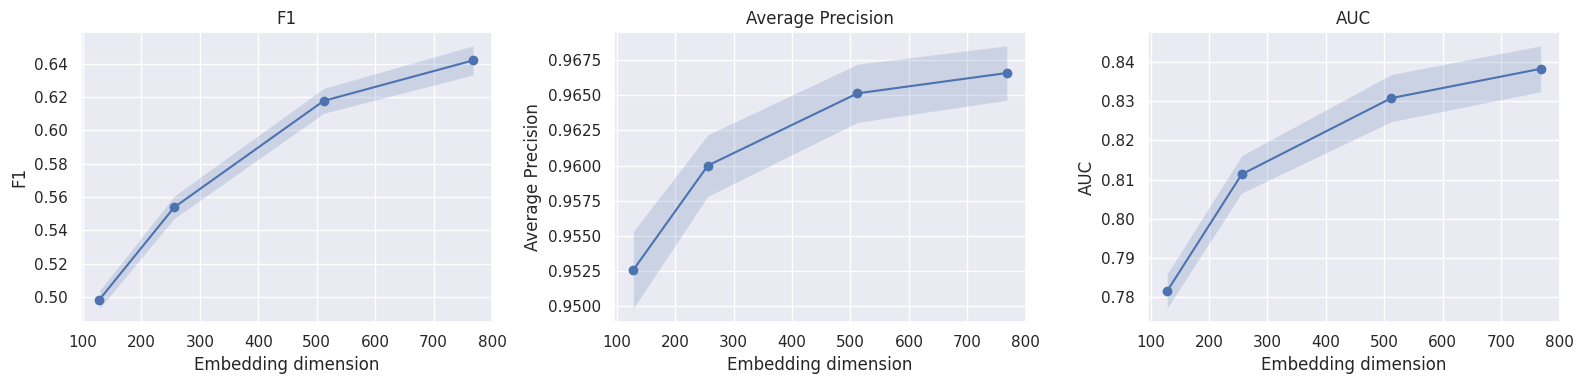

In [40]:
import seaborn as sns
dims = [r['dim'] for r in json_data_emb][:-1]

# Metrics for CV/train (with std)
metrics_cv = ['F1', 'AvgPrec', 'AUC', ] # 'Precision', 'Recall'

# Metrics for test
metrics_test = ['f1', 'avg_prec', 'auc',] # 'precision', 'recall'
sns.set_theme(style="darkgrid")

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, (m_cv, m_test) in enumerate(zip(metrics_cv, metrics_test)):
    cv_vals = [r[m_cv] for r in json_data_emb][:-1]
    cv_std = [r[m_cv + '_std'] for r in json_data_emb][:-1]
    test_vals = [r[m_test] for r in json_data_emb][:-1]

    ax = axes[i]
    
    # CV metric with error bars
    # ax.errorbar(dims, cv_vals, yerr=cv_std, label='CV/train', marker='o', capsize=3)
    ax.plot(dims, cv_vals, marker='o')
    
    # Test metric
    # ax.plot(dims, test_vals, label='Test', marker='s')

    ax.fill_between(
            dims,
            np.array(cv_vals) - np.array(cv_std),
            np.array(cv_vals) + np.array(cv_std),
            alpha=0.2,
        )
    
    ax.set_title(m_cv)
    if m_cv == "AvgPrec":
        ax.set_title("Average Precision")
    ax.set_xlabel('Embedding dimension')
    ax.set_ylabel(m_cv.replace("AvgPrec", "Average Precision"))
    ax.grid(True)
    # ax.legend()

plt.tight_layout()
plt.savefig("images/pretest/embed_size_metrics.pdf")
plt.show()


### 5. Test of different embeddings

In [ ]:
RESULTS = []  # accumulate across all cells

def run_cv(X, y, n_splits=5, scaling = True):
    """Scale + LR inside a pipeline, return mean CV metrics."""
    if scaling :
        pipe = Pipeline([
            # ("scaler", StandardScaler()),
            ("clf",    LogisticRegression(solver="lbfgs", max_iter=2000))
        ])
    else:
        pipe = Pipeline([
            ("clf",    LogisticRegression(solver="lbfgs", max_iter=2000))
        ])
    
    scores = cross_validate(pipe, X, y, cv=n_splits,
                            scoring=["f1_macro", "roc_auc",
                                     "average_precision",
                                     "precision_macro", "recall_macro"])
    return {
        "F1":            scores["test_f1_macro"].mean(),
        "F1_std":        scores["test_f1_macro"].std(),
        "AUC":           scores["test_roc_auc"].mean(),
        "AUC_std":       scores["test_roc_auc"].std(),
        "AvgPrec":       scores["test_average_precision"].mean(),
        "AvgPrec_std":   scores["test_average_precision"].std(),
        "Precision":     scores["test_precision_macro"].mean(),
        "Precision_std": scores["test_precision_macro"].std(),
        "Recall":        scores["test_recall_macro"].mean(),
        "Recall_std":    scores["test_recall_macro"].std(),
    }

def mean_embed_wv(texts, model): # sitck mean
    vecs = []
    for text in texts:
        words = text.split()
        ws = [model.wv[w] for w in words if w in model.wv]
        vecs.append(np.mean(ws, axis=0) if ws else np.zeros(model.vector_size))
    return np.array(vecs)

def log_result(name, metrics):
    RESULTS.append({"model": name, **metrics})
    print(f"{name:40s} : F1={metrics['F1']:.4f}  AUC={metrics['AUC']:.4f}")

all_texts = [stopwords_rmv(prep.process(t)) for t in X_train]
all_texts_tok = [t.split() for t in all_texts]

BEST_SIZE = 200 

#### Count + tfidf

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline as SKPipeline
from sklearn.model_selection import train_test_split, cross_validate

# no StandardScaler here — sparse matrices, TF-IDF already normalized
def run_cv_sparse(X, y, n_splits=5):
    clf = LogisticRegression(solver="lbfgs", max_iter=1000)
    scores = cross_validate(clf, X, y, cv=n_splits,
                            scoring=["f1_macro", "roc_auc",
                                     "average_precision",
                                     "precision_macro", "recall_macro"])
    return {
        "F1":            scores["test_f1_macro"].mean(),
        "F1_std":        scores["test_f1_macro"].std(),
        "AUC":           scores["test_roc_auc"].mean(),
        "AUC_std":       scores["test_roc_auc"].std(),
        "AvgPrec":       scores["test_average_precision"].mean(),
        "AvgPrec_std":   scores["test_average_precision"].std(),
        "Precision":     scores["test_precision_macro"].mean(),
        "Precision_std": scores["test_precision_macro"].std(),
        "Recall":        scores["test_recall_macro"].mean(),
        "Recall_std":    scores["test_recall_macro"].std(),
    }

cv_vec   = CountVectorizer()
tfidf_vec = TfidfVectorizer()

X_cv    = cv_vec.fit_transform(all_texts)
X_tfidf = tfidf_vec.fit_transform(all_texts)

log_result("CountVectorizer",  run_cv_sparse(X_cv,    y_train))
log_result("TF-IDF", run_cv_sparse(X_tfidf, y_train))

CountVectorizer                          : F1=0.7108  AUC=0.8551
TF-IDF                                   : F1=0.6258  AUC=0.8574


#### Word2V, Fastext, D2V

In [13]:
from gensim.models import Word2Vec, FastText
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.pipeline import Pipeline

# Word2Vec
w2v = Word2Vec(sentences=all_texts_tok, vector_size=BEST_SIZE,
               window=5, min_count=5, sg=1, epochs=5, workers=3)
log_result(f"Word2Vec (trained {BEST_SIZE}d)", run_cv(mean_embed_wv(all_texts, w2v), y_train))

# FastText
ft = FastText(sentences=all_texts_tok, vector_size=BEST_SIZE,
              window=5, min_count=1, sg=1, epochs=5, workers=3)
log_result(f"FastText (trained {BEST_SIZE}d)", run_cv(mean_embed_wv(all_texts, ft), y_train))

# Doc2Vec
tagged = [TaggedDocument(t.split(), [i]) for i, t in enumerate(all_texts)]
d2v = Doc2Vec(tagged, vector_size=BEST_SIZE, window=5,
              min_count=1, dm=0, epochs=20, workers=4)

X_d2v = np.array([d2v.infer_vector(t.split()) for t in all_texts])
log_result(f"Doc2Vec (trained {BEST_SIZE}d)", run_cv(X_d2v, y_train))

Word2Vec (trained 200d)                  : F1=0.5316  AUC=0.7842
FastText (trained 200d)                  : F1=0.5313  AUC=0.7787
Doc2Vec (trained 200d)                   : F1=0.5974  AUC=0.7826


#### W2V, Fastext pretrained (ran ppti)

python file w2v_ft_res.py

In [ ]:
from gensim.models import KeyedVectors
from gensim.models.fasttext import load_facebook_model

# cc.fr.300.vec — behaves like Word2Vec, no subword info
kv_vec = KeyedVectors.load_word2vec_format("cc.fr.300.vec", binary=False)
log_result("cc.fr.300.vec (W2V-like)", run_cv(mean_embed_wv(all_texts, type('M', (), {'wv': kv_vec, 'vector_size': 300})()), y_train))

# cleaner helper that works directly with KeyedVectors
def mean_embed_kv(texts, kv):
    vecs = []
    for text in texts:
        words = text.split()
        ws = [kv[w] for w in words if w in kv]
        vecs.append(np.mean(ws, axis=0) if ws else np.zeros(kv.vector_size))
    return np.array(vecs)

log_result("cc.fr.300.vec (W2V-like)", run_cv(mean_embed_kv(all_texts, kv_vec), y_train))

ft_bin = load_facebook_model("cc.fr.300.bin")
log_result("cc.fr.300.bin (FastText)",  run_cv(mean_embed_wv(all_texts, ft_bin), y_train))

In [58]:
with open("w2v_ft_results.json") as json_file:
    json_data_w2v_ft = json.load(json_file)

In [59]:
log_result("Word2Vec", json_data_w2v_ft[0])
log_result("FastText", json_data_w2v_ft[1])

Word2Vec                                 : F1=0.5588  AUC=0.7919
FastText                                 : F1=0.5688  AUC=0.7982


In [ ]:
# tmp sav
RESULTS

[{'model': 'CountVectorizer',
  'F1': np.float64(0.7107755401548113),
  'F1_std': np.float64(0.0023119873468460217),
  'AUC': np.float64(0.8551356586808134),
  'AUC_std': np.float64(0.005133350290685036),
  'AvgPrec': np.float64(0.9704856842962715),
  'AvgPrec_std': np.float64(0.0016004048988171055),
  'Precision': np.float64(0.8054680312654723),
  'Precision_std': np.float64(0.005292903690409735),
  'Recall': np.float64(0.6703569677447078),
  'Recall_std': np.float64(0.002387635175341692)},
 {'model': 'TF-IDF',
  'F1': np.float64(0.6258414647617534),
  'F1_std': np.float64(0.005271053345967234),
  'AUC': np.float64(0.8573911765661943),
  'AUC_std': np.float64(0.002944437844377875),
  'AvgPrec': np.float64(0.9717770274068764),
  'AvgPrec_std': np.float64(0.0008801304888786758),
  'Precision': np.float64(0.8450478165609656),
  'Precision_std': np.float64(0.00925318403843749),
  'Recall': np.float64(0.5935133144802976),
  'Recall_std': np.float64(0.003754421874749323)},
 {'model': 'Word2

#### Transformers

In [ ]:
# from sentence_transformers import SentenceTransformer

# model = SentenceTransformer(
#     "intfloat/multilingual-e5-base", 
# )
# model.save("./model_emb")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4303.94it/s]
XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Writing model shards: 100%|██████████| 1/1 [00:04<00:00,  4.75s/it]


In [53]:
from sentence_transformers import SentenceTransformer

# texts WITHOUT stopword removal for transformers
raw_texts = [prep.process(t) for t in X_train]  # light prep, keep stopwords

st_model = SentenceTransformer("./model_emb", device = "cpu")

X_st = st_model.encode(raw_texts, batch_size=8, show_progress_bar=True)
log_result(f"Transformer ({model_name.split('/')[-1]})", run_cv(X_st, y_train))

Batches: 100%|██████████| 5742/5742 [41:00<00:00,  2.33it/s] 


NameError: name 'model_name' is not defined

In [54]:
log_result(f"Transformer (embed)", run_cv(X_st, y_train))

Transformer (embed)                      : F1=0.6382  AUC=0.8360


In [60]:
RESULTS 

[{'model': 'CountVectorizer',
  'F1': np.float64(0.7107755401548113),
  'F1_std': np.float64(0.0023119873468460217),
  'AUC': np.float64(0.8551356586808134),
  'AUC_std': np.float64(0.005133350290685036),
  'AvgPrec': np.float64(0.9704856842962715),
  'AvgPrec_std': np.float64(0.0016004048988171055),
  'Precision': np.float64(0.8054680312654723),
  'Precision_std': np.float64(0.005292903690409735),
  'Recall': np.float64(0.6703569677447078),
  'Recall_std': np.float64(0.002387635175341692)},
 {'model': 'TF-IDF',
  'F1': np.float64(0.6258414647617534),
  'F1_std': np.float64(0.005271053345967234),
  'AUC': np.float64(0.8573911765661943),
  'AUC_std': np.float64(0.002944437844377875),
  'AvgPrec': np.float64(0.9717770274068764),
  'AvgPrec_std': np.float64(0.0008801304888786758),
  'Precision': np.float64(0.8450478165609656),
  'Precision_std': np.float64(0.00925318403843749),
  'Recall': np.float64(0.5935133144802976),
  'Recall_std': np.float64(0.003754421874749323)},
 {'model': 'Word2

                   model       F1   F1_std      AUC  AUC_std  AvgPrec  AvgPrec_std  Precision  Precision_std   Recall  Recall_std
         CountVectorizer 0.710776 0.002312 0.855136 0.005133 0.970486     0.001600   0.805468       0.005293 0.670357    0.002388
                  TF-IDF 0.625841 0.005271 0.857391 0.002944 0.971777     0.000880   0.845048       0.009253 0.593513    0.003754
 Word2Vec (trained 200d) 0.531644 0.004075 0.784213 0.007982 0.955020     0.001636   0.676570       0.017615 0.532735    0.002450
 FastText (trained 200d) 0.531326 0.008064 0.778702 0.007059 0.953680     0.001567   0.678098       0.023325 0.532603    0.004898
  Doc2Vec (trained 200d) 0.597400 0.004603 0.782554 0.003371 0.952957     0.000916   0.781072       0.007129 0.574742    0.003205
     Transformer (embed) 0.638209 0.009542 0.835986 0.006431 0.966087     0.001887   0.820268       0.005835 0.603599    0.007213
cc.fr.300.vec (W2V-like) 0.558755 0.004718 0.791933 0.004566 0.955847     0.001592   0.686

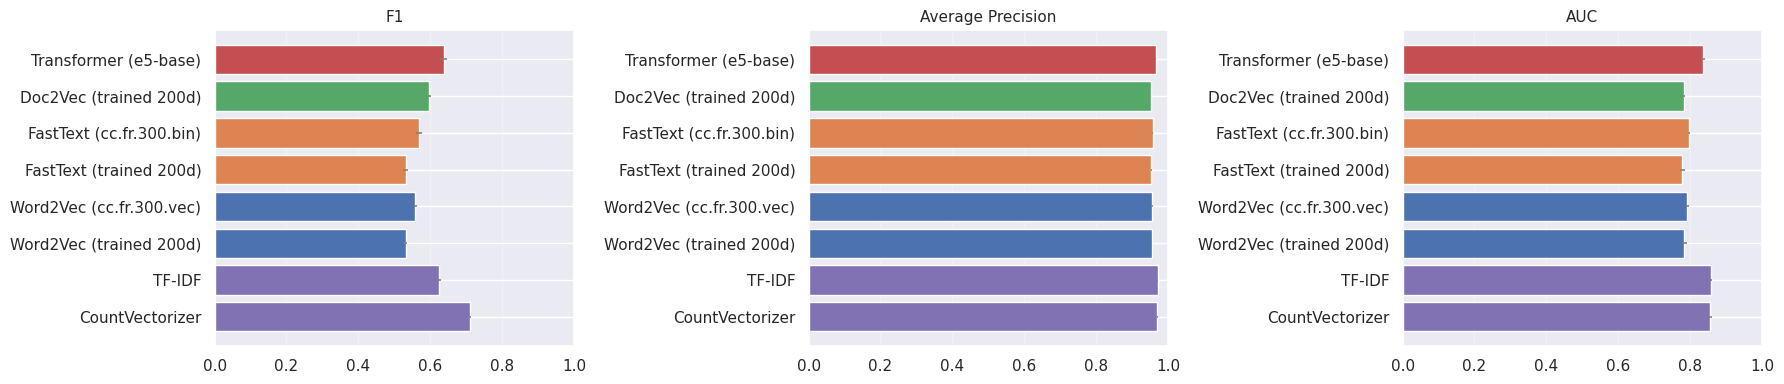

In [97]:
import pandas as pd
import matplotlib.pyplot as plt

df_results = pd.DataFrame(RESULTS)
print(df_results.to_string(index=False))


order = [
    "CountVectorizer",
    "TF-IDF",
    "Word2Vec (trained 200d)",
    "cc.fr.300.vec (W2V-like)",
    "FastText (trained 200d)",
    "cc.fr.300.bin (FastText)",
    "Doc2Vec (trained 200d)",
    "Transformer (embed)",
]

df_plot = df_results.set_index("model").reindex([m for m in order if m in df_results["model"].values]).reset_index()
df_plot = df_plot.replace({
    "cc.fr.300.vec (W2V-like)": "Word2Vec (cc.fr.300.vec)",
    "cc.fr.300.bin (FastText)": "FastText (cc.fr.300.bin)",
    "Transformer (embed)": "Transformer (e5-base)",})

# same plotting code as before, adapted for model names on x axis

METRICS = ["F1", "AvgPrec" , "AUC", ] #  "Precision", "Recall"
LABELS  = ["F1", "Average Precision", "AUC", ]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, metric, label in zip(axes, METRICS, LABELS):
    vals = df_plot[metric]
    colors = [sns.color_palette()[0] if "Word2Vec" in m 
              else sns.color_palette()[1] if "Fast" in m
              else sns.color_palette()[2] if "Doc" in m
              else sns.color_palette()[3] if "Transformer" in m
              else sns.color_palette()[4]
              for m in df_plot["model"]]
    ax.barh(df_plot["model"], vals, color=colors, xerr=df_plot[f"{metric}_std"], error_kw={"elinewidth": 1.2, "ecolor": "gray"})
    ax.set_title(label, fontsize=11)
    ax.set_xlim(0, 1)
    # ax.spines[["top","right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("images/pretest/vectorizer_comparison.pdf", dpi=150, bbox_inches="tight")
plt.show()

### 6. POS Tag RNN (ran PPTI)

python file pos_tag_rnn.py

## Re baseline

class majoritary

In [ ]:
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score, precision_score, recall_score    

f1_train, f1_test = f1_score(y_train, np.ones(len(y_train)), average='macro'), f1_score(y_test, np.ones(len(y_test)), average='macro')
ap_train, ap_test = average_precision_score(y_train, np.ones(len(y_train))), average_precision_score(y_test, np.ones(len(y_test)))
auc_train, auc_test = roc_auc_score(y_train, np.ones(len(y_train))), roc_auc_score(y_test, np.ones(len(y_test)))
prec_train, prec_test = precision_score(y_train, np.ones(len(y_train))), precision_score(y_test, np.ones(len(y_test)), average='macro')
rec_train, rec_test = recall_score(y_train, np.ones(len(y_train))), recall_score(y_test, np.ones(len(y_test)), average='macro')

print(auc_train, auc_test)
print(f1_train, f1_test)
print(ap_train, ap_test)
print(rec_train, rec_test)
print(prec_train, prec_test)

0.5 0.5
0.4649472286293423 0.46493639625366945
0.8689745264532985 0.8689366890185491
1.0 0.5
0.8689745264532985 0.4344683445092746


/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


random predictions, over 30 runs 

In [58]:
np.random.seed(0)
n_runs = 30

f1_train_scores, f1_test_scores = [], []
ap_train_scores, ap_test_scores = [], []
auc_train_scores, auc_test_scores = [], []
prec_train_scores, prec_test_scores = [], []
rec_train_scores, rec_test_scores = [], []

for _ in range(n_runs):
    a = np.random.choice([-1, 1], size=len(y_train))
    b = np.random.choice([-1, 1], size=len(y_test))

    f1_train_scores.append(f1_score(y_train, a, average="macro"))
    f1_test_scores.append(f1_score(y_test, b, average="macro"))

    ap_train_scores.append(average_precision_score(y_train, a))
    ap_test_scores.append(average_precision_score(y_test, b))

    auc_train_scores.append(roc_auc_score(y_train, np.where(a == 1, 1, 0)))
    auc_test_scores.append(roc_auc_score(y_test, np.where(b == 1, 1, 0)))

    prec_train_scores.append(precision_score(y_train, a, average='macro'))
    prec_test_scores.append(precision_score(y_test, b, average='macro'))

    rec_train_scores.append(recall_score(y_train, a, average='macro'))
    rec_test_scores.append(recall_score(y_test, b, average='macro'))

print("Mean over 30 random runs:")
print("AUC:", np.mean(auc_train_scores), np.mean(auc_test_scores))
print("F1:", np.mean(f1_train_scores), np.mean(f1_test_scores))
print("AP:", np.mean(ap_train_scores), np.mean(ap_test_scores))
print("Recall:", np.mean(rec_train_scores), np.mean(rec_test_scores))
print("Precision:", np.mean(prec_train_scores), np.mean(prec_test_scores))

Mean over 30 random runs:
AUC: 0.5008081654681841 0.4998535216013436
F1: 0.4214766679305052 0.42074730693105805
AP: 0.8691598115777023 0.8689088772530399
Recall: 0.5008081654681842 0.49985352160134355
Precision: 0.5003680675841884 0.49993328426316347
